---

Intro

While reading about recent SRF research, I found it interesting that samples which underwent typical LTB treatment regimes were found to have flux vortex penetration under DC fields exactly at $B=B_{c1}$ the lower critical field [1][2]. This was a bit suprising to me for two particular reasons:

- Low temperature baked (and other surface doped cavities) sustain some of the highest field gradients ~50MV/M, 200mT max surface field [3]
- Various works have suggested that surface doping improves the Bean-Livingston Barrier [4][5][6], often attributed to preventing flux penetration.
<!-- - The primary source of resistance in dirty-surface cavities is attributed to various sources [citation needed] -->

It also appears as though there are varying descriptions of what exactly causes losses in the high-field regime, both with HFQS present [citation needed][7] and not present [citation needed][8]

The authors of [2] are particularly vocal about the subject, stating that the results of their study and a few related ones suggest that Low Temperature Baking does *not* create a superconductor/superconductor bilayer, and RF flux penetration must be delayed instead as a result of a non-homogeneous superconductor. This discussion, alongside a few of the papers cited in [2], drove me to investigate how DC and RF flux penetration differ and see if I could connect the concept of non-homogeneous superconductivity.

Note: I turned in a similar version of this project for Phys510 quantum mechanics, which went into depth on Larkin & Ovchinnikov instability for Quantized Flux Vorticies instead of solving the penetrating fields.

<br>[1] No interface energy barrier and increased surface pinning in low temperature baked niobium [DOI](http://doi.org/10.1038/s41598-022-09023-0)
<br>[2] Measurements of the first-flux-penetration field in surface-treated and coated Nb: distinguishing between near-surface pinning and an interface energy barrier [DOI](https://doi.org/10.1088/1361-6668/ad54f3)
<br>[3] Gradients of 50 MV/m in TESLA Shaped Cavities via Modified Low Temperature Bake [DOI](http://jacow.org/srf2019/papers/tup061.pdf) 
<br>[4] Multilayer coating for higher accelerating fields in superconducting radio-frequency cavities: a review of theoretical aspects [DOI](https://doi.org/10.1088/1361-6668/30/2/023001)
<br>[5] Nitrogen doping and infusion in SRF cavities: A review [DOI](https://doi.org/10.1016/j.physo.2020.100034)
<br>[6] Mattia Checchin PhD [osti.gov](https://www.osti.gov/biblio/1348232), [DOI](https://doi.org/10.2172/1348232)
<br>[7]Magneto-thermal limitations in superconducting cavities at high radio-frequency fields [DOI](https://doi.org/10.3389/femat.2024.1339293)
<br>[8]Enhancement of medium-temperature heat-treated SRF cavities for high quality and high gradient [SRF2025](https://indico.jacow.org/event/89/contributions/8883), [paper](https://meow.elettra.eu/89/doi/jacow-srf2025-tua05/index.html)
<br>[9] Dynamics of vortex penetration, jumpwise instabilities and nonlinear surface  resistance of type-II superconductors in strong rf fields [DOI](https://doi.org/10.1103/PhysRevB.77.104501) 
<!-- <br>[i] Daniel Bafia PhD -->

<div style="page-break-after: always"> </div>

---

The Model

To model the behavior of magnetic field penetration, I chose to recreate some of the dynamics in [6]. The primary divergence is the use of an inhomogeneous superconductor. To do this, we assume that the mean free path $\ell$ is depth-dependent at the nanometer scale, and connect various superconducting parameters to this value. In the dirty limit, the pippard local model yields [10]

$$
\begin{gathered}
    \lambda = \lambda_L \sqrt{1 + {\xi_0 \over \ell}},
\\  {1 \over \xi_s} = {1 \over \ell} + {1 \over \xi_0}
\end{gathered}
$$
In the dirty limit, the $\xi_s$ formula becomes $\xi_s = \sqrt{\xi_0 \ell}$. Other models have used logistical curves to interpolate, especially in discussion around bilayer systems [6], [11]. From these, I used the second london equation and a `scipy` differential equation solver to get the magnetic field inside the heterogeneous superconductor

$$
        \vec J 
    = - {1 \over \mu_0 \lambda^{2}(\vec x)} \vec A.
        % \lambda^2(\vec x) \mu_0 \vec J 
$$

I considered using more advanced methods for solving for the fields inside, such as using Usadel equations [11][12] or Ginzburg-Landau equations as in [13], but at this point I didn't want to get involved with varying the superconducting order parameter for the proof of concept.

RF fluxons: the main equation describing penetrating vortex dynamics in the original paper is Eq. (32) [9]

$$
        {\eta_0 \dot x \over 1+\dot x^2 / v_0^2} 
    = F(x,t)
    =   \underbrace{{\phi_0 B_0 \over \mu_0 \lambda} e^{-x/\lambda}\sin \omega t}_{\text{applied field interaction}}
    -   \underbrace{{\phi_0^2 \over 2\pi \mu_0 \lambda^3} K_1 \left[{2 \over \lambda} \sqrt{x^2 + \xi_s^2}\right]}_{\text{image field interaction}},
$$
where the vortex is modeled as a massless point and $v_0$ is the maximum drag force capable of balancing the net force of the applied magnetic field lorentz force and surface interaction lorentz force. In this equation, the surface interaction is regularized by approximating distance to the surface as $x_{eff} = \sqrt{x^2 + \xi_s^2}$. This equation might better be understood as the gradient of the gibbs free energy (derived from [6]). In this model, vortex penetration occurs when $F(u=0)>0$, but full simulation of vortex dynamics is needed to determine if the vortex will fully penetrate or return to the surface in one RF cycle.

$$
F(x, t) = -\nabla G(x, t) \approx -\nabla \left[ 
    \phi_0 H_{\text{applied}}(x, t) + \phi_0 H_{\text{surface}}(x) + \phi_0 H_{\text{c1}}(x)
\right].
$$



Solving for $H_{\text{applied}}$ in the London Gauge requires solving the simple 1D differential equation rigorously derived below:

<div style="border:1px solid #cacaca; padding:1em; margin:1em 0; background:#f8f8f8; border-radius:8px; page-break-after: always;">

From the london gauge we have

$$
\begin{gathered}
        \vec J 
    = - {1 \over \mu_0 \lambda^{2}(\vec x)} \vec A,
\\      \lambda^2(\vec x) \mu_0 \vec J 
    = - \vec A,

\\      \nabla \times \left[\lambda^2(\vec x) \mu_0 \vec J \right]
    = - \nabla \times \vec A,
\\      \nabla \times \left[\lambda^2(\vec x) \left(\nabla \times \vec B\right) \right]
    = - \vec B.

\end{gathered}
$$
Converting to 1D we have depth-dependent $\lambda(\vec x) = \lambda(x)$ and $\vec B = B(x) \hat z$

$$
\begin{gathered}
        \nabla \times \vec B 
    = - {\partial B \over \partial x} \hat y,
\\      \nabla \times \left[\lambda^2 {\partial B \over \partial x} \hat y \right]
    =   B \hat z,
\\      \lambda^2\nabla \times \left({\partial B \over \partial x} \hat y\right)
    +   \nabla \lambda^2 \times \left({\partial B \over \partial x} \hat y\right)
    =   B \hat z,
\\      \lambda^2 {\partial^2 B \over \partial x^2} \hat z
    +   {\partial \lambda^2 \over \partial x} {\partial B \over \partial x} \hat z
    =   B \hat z.
\end{gathered}
$$
Dropping the vector notation, we can write the self-adjoint result as
$$
\begin{gathered}
        {d \over dx}\left(\lambda^2 {d B \over dx} \right)-B 
    =   0,
% \\      \ddot B
%     +   2 \lambda^{-1} \dot \lambda \dot B 
%     -     \lambda^{-2} B
%     =   0
\end{gathered}
$$

</div>

which is equivalent to Eq. (1) of [14]. $H_{\text{surface}}$ is slightly more complicated, since it represents a flux source term. Using ${d \over dx}\left(\lambda^2 {d B \over dx} \right)-B = \delta(x)$ represents a flat plane source, not a point source, so the 2D equation must be used to represent a fluxon.

<div style="border:1px solid #cacaca; padding:1em; margin:1em 0; background:#f8f8f8; border-radius:8px; page-break-after: always;">

$$
\begin{gathered}
        \nabla \times \left[
        \lambda^2(x) \left( \nabla \times B(x,y)\hat z\right)
    \right]
    +   B(x,y) \hat z
    =   \phi_0\delta(y)\delta(x-x_0) \hat z,
% \\      \nabla \times \left[
%             \lambda^2(x){\partial B \over \partial y} \hat x 
%         -   \lambda^2(x){\partial B \over \partial x} \hat y
%         \right]
%     +   B(x,y) \hat z
%     =   \phi_0\delta(y)\delta(x-x_0) \hat z
% \\  -   \lambda^2(x){\partial^2 B \over \partial y^2} \hat z     
%     -   {\partial \over \partial x}\lambda^2(x){\partial B \over \partial x} \hat z
%     +   B(x,y) \hat z
%     =   \phi_0\delta(y)\delta(x-x_0) \hat z
\\  -   \lambda^2(x){\partial^2 B \over \partial y^2}
    -   {\partial \over \partial x}\left(\lambda^2(x){\partial B \over \partial x}\right)
    +   B(x,y)
    =   \phi_0\delta(y)\delta(x-x_0)
\end{gathered}
$$

We could solve on a 2D grid, but that might be less accurate. Instead, we'll take the fourier transform along the y-axis, yielding

$$
\begin{gathered}
        k^2 \lambda^2(x) B(x,k)
    -   {\partial \over \partial x}\left(\lambda^2(x){\partial B(x,k) \over \partial x}\right)
    +   B(x,k)
    =   \phi_0\delta(x-x_0)
\\  {\partial \over \partial x}\left(\lambda^2(x){\partial B(x,k) \over \partial x}\right)
    -   \left[1+k^2\lambda^2(x)\right]B(x,k)
    = - \phi_0\delta(x-x_0)
\end{gathered}
$$

</div>

which is entirely 1D. I've implemented this with y-array length computed automatically so that the discrete fourier transform observes $B(y\rightarrow \infty) = 0$ and causes higher order $k$ values to be damped out. The relatively fast SOLDE solver is able to solve for $B(x,y) = \sum_k B(x,k)$ relatively quickly.

The last component is vortex size. $H_{c1}$ is irrelevant in most dynamics implementations, but with varying $\xi$ it developes a $\ell(x)$ dependence as

$$
- {d B_{c1} \over dx} \sim -{d \over dx} \left( \ln (\kappa (x)) \over \lambda^2(x)\right).
$$

In addition, I tried to represent this $\ell$ dependence in my BVP solver, representing the fluxon as a gaussian distribution as

$$
f(x,y)=- \phi_0 \delta(x-x_0)\delta(x) \rightarrow -{\phi_0 \exp\left({-(x-x_0)^2-y^2 \over 2 \xi^2(x)}\right) \Big/ 2 \pi \xi^2(x)}
$$

which is easily transformed to $k$-space as the product

$$
f(x,k)= -{\phi_0 \exp\left({-(x-x_0)^2 \over 2 \xi^2(x)}\right) \exp\left(-\xi^2(x)k^2 \over 2\right)\Big/ \sqrt{2 \pi} \xi(x)}
$$

As a separable function $f(x,k)=X(x)K(k)$, this has good convergence and the field produced is easily calculated by the SOLDE solver. The idea for this originally comes from [15] which uses a similar distribution, except the fourier transform there is not separable like the gaussian.

Below is the solution to the code with the same parameters as in [9], as well as a crude approximation of the field this model expects for the N-Infused cavity from [16]

<div style="page-break-after: always"> </div>

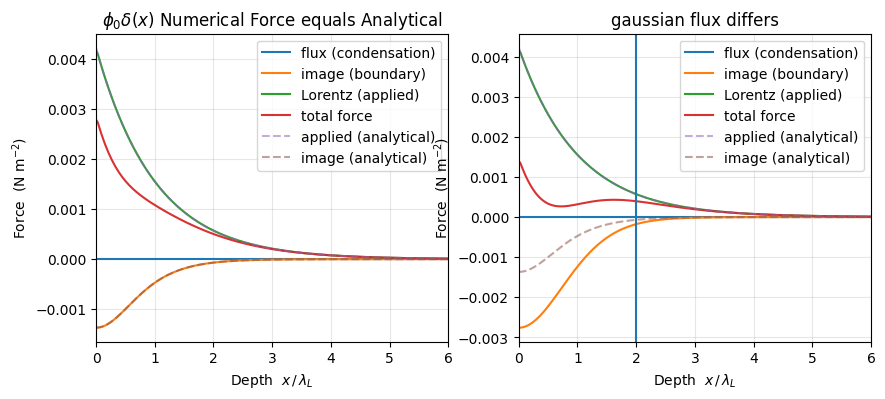

In [1]:
from vortex_sim import nonhomogeneous_sc, plotter, ell_extracted, phi0, mu_0
import matplotlib.pyplot as plt
import numpy as np

# bulk params
lambda_L = 39e-9

# deep enough for B(x->max(x)) = 0
resolution = 1000
depth_grid =  np.linspace(0, 30*lambda_L, resolution)

# default vals are for bulk Nb from Gurevich & Ciovati 2008 
basic_sc = nonhomogeneous_sc(
    M = 301,            # FFT y-grid points
    interpolate=True,   # xeff = sqrt(x**2 + xi**2)
    gaussian=False
)
basic_sc.load_depth_dependence(
    x=depth_grid,
    xi_s=np.ones(resolution)*basic_sc.xi0,
    lambda_s=np.ones(resolution)*basic_sc.lambda_L
)

# --- # plotting # --- #

basic_sc.gibbs(); # computes fields and gibbs profile
basic_sc_plot = plotter(basic_sc)
fig, (ax0, ax1) = plt.subplots(1, 2, sharex=True, figsize=(10,4))

basic_sc_plot.plot_force(ax=ax0, analytical=True, components=True)
ax0.set_title(r'$\phi_0\delta(x)$ Numerical Force equals Analytical')
ax0.set_xlim(0,6)

basic_sc_plot.sc.gaussian = True
basic_sc_plot.sc.gibbs(); # recomputes fields with gaussian

basic_sc_plot.plot_force(ax=ax1, analytical=True, components=True)
ax1.set_title(r'gaussian flux differs')
ax1.axvline(2)

Note the differeing y-axis, as the gaussian has a stronger surfce interaction in this limit. The plot below shows how the point flux and gaussian flux differ.

<div style="page-break-after: always"> </div>

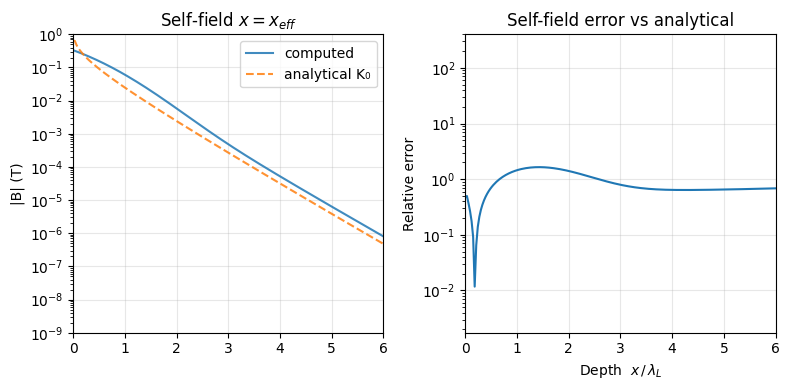

In [2]:
fig, axes = plt.subplots(1,2, figsize=(8,4), sharex=True)

basic_sc_plot.plot_self_field(axes=axes)
axes[0].set_title(r'Self-field $x=x_{eff}$')
axes[0].set_ylim(1e-9, 1)
axes[0].set_xlim(0,6)
plt.tight_layout()

The solution using a gaussian fluxon varies from the analytical point fluxon by a maximum 200%, which is pretty good for this toy model. The plot below implements a non-homogeneous superconductor using a crude approximation of the impurity concentration TOF-SIMS curve from [16] as an exponential, then uses the formula $\ell = {1 \over c \pi r}$ to convert to local mean free path. The purpose of this is to have some backing for the slope of $\ell$ moreso than physical accuracy.

<div style="page-break-after: always"> </div>

max mfp: 8.95 nm


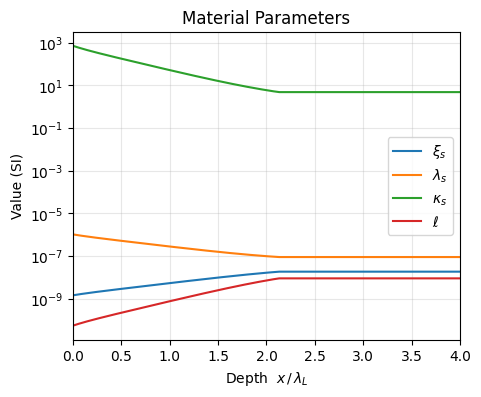

In [3]:
paper_sc = nonhomogeneous_sc(
    M=301,
    gaussian=True,
    interpolate=False,
    B0=.2 # 200 mT
)

mfp = ell_extracted(depth_grid*1e9)
lambda_s = paper_sc.lambda_L*np.sqrt(1+paper_sc.xi0/mfp)
xi_s = np.sqrt(mfp*paper_sc.xi0)

paper_sc.load_depth_dependence(depth_grid, lambda_s=lambda_s, xi_s=xi_s)

paper_sc_plotter = plotter(paper_sc)
fig, ax = plt.subplots(1,1, figsize=(5,4))
paper_sc_plotter.plot_material(ell=mfp, ax=ax, y_norm=False)
ax.set_yscale('log')
ax.set_xlim(0, 4)
print(f'max mfp: {mfp[-1]*1e9:.2f} nm')

The plotted region never quite converges to the ~$90 \text{nm}$ value for mean free path $\ell$ computed in Hannah Hu's paper. I wanted to stay strictly in the dirty region so I assumed that the dirty region extends into the bulk rather than approaching the average concentration computed from the cylindrical cut of the TOF-SIMS data used in [16], which is a requirement that can be relaxed if the toy model is improved later. The resulting field and Gibbs Free energy are

<div style="page-break-after: always"> </div>

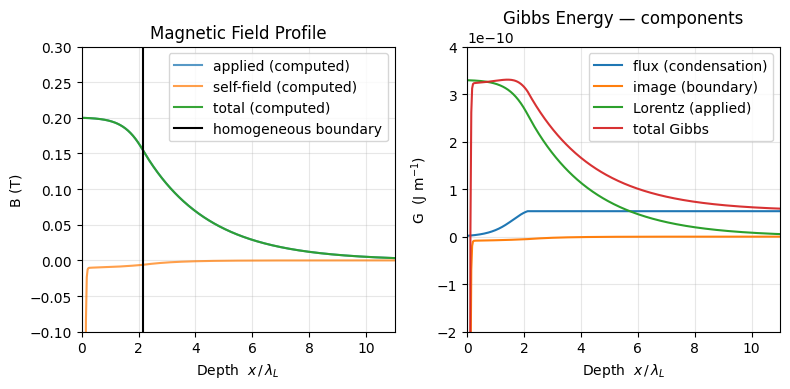

In [4]:
paper_sc_plotter.sc.gibbs()

fig, (ax0, ax1) = plt.subplots(1,2, figsize=(8,4), sharex=True)
paper_sc_plotter.plot_B(components=True, ax = ax0)
ax0.set_ylim(-0.1, 0.3)
ax0.set_xlim(0, 11)
ax0.axvline(84e-9/paper_sc.lambda_L, label='homogeneous boundary', color='black')
ax0.legend()

paper_sc_plotter.plot_gibbs(ax1, components=True)
ax1.set_ylim(-2e-10, 4e-10)

plt.tight_layout()

Remember that I am approximating the inhomogeneous portion ending at $x=84 \text{nm}$. Considering how deep the magnetic field penetrates here, we should probably model the dopants continuing to decrease a bit further. The curve below matches the same slope as the data from [16], just with the maximum $\ell$ increased from $9\text{nm}$ to $20\text{nm}$, allowing for a shorter $\lambda(x)$ and quicker decay of $B$ further into the superconductor.

<div style="page-break-after: always"> </div>

max mfp: 8.95 nm


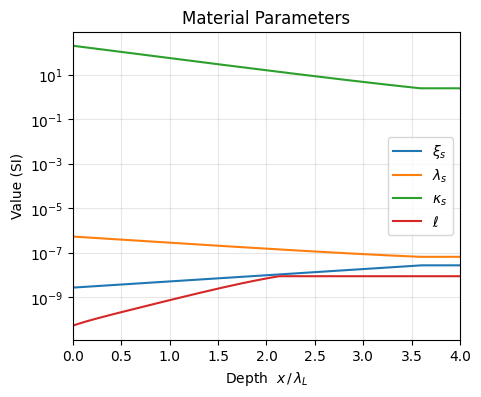

In [5]:
toy_sc = nonhomogeneous_sc(M=301, gaussian=True, interpolate=False, B0=.2) # bulk Nb

a = 0.2e-9
b = 1/(30.38e-9)

l_func = lambda x: np.minimum(a*np.exp(x*b), 20e-9)
l = l_func(depth_grid)
lambda_s = toy_sc.lambda_L*np.sqrt(1+toy_sc.xi0/l)
xi_s = np.sqrt(toy_sc.xi0*l)

toy_sc.load_depth_dependence(depth_grid, lambda_s=lambda_s, xi_s=xi_s)

toy_plotter = plotter(toy_sc)
fig, ax = plt.subplots(1,1, figsize=(5,4))
toy_plotter.plot_material(ell=mfp, ax=ax, y_norm=False)
ax.set_yscale('log')
ax.set_xlim(0, 4)
print(f'max mfp: {mfp[-1]*1e9:.2f} nm')

<div style="page-break-after: always"> </div>

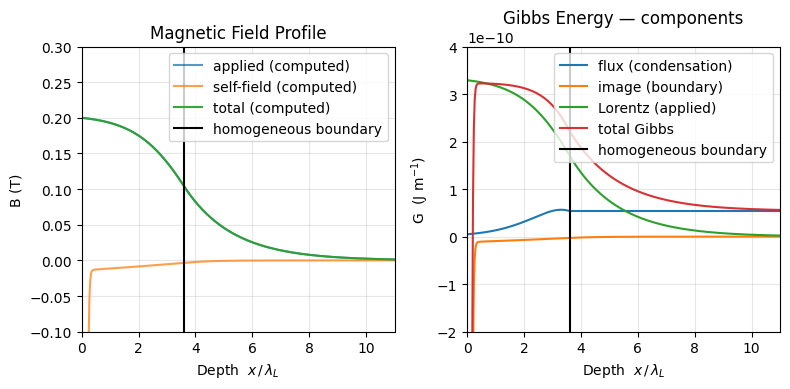

In [6]:
bound = toy_plotter.sc.x[np.argmax(l-l[-1])]/paper_sc.lambda_L

toy_plotter.sc.gibbs() # the part that takes a minute

fig, (ax0, ax1) = plt.subplots(1,2, figsize=(8,4), sharex=True)
toy_plotter.plot_B(components=True, ax = ax0)
ax0.set_ylim(-0.1, 0.3)
ax0.set_xlim(0, 11)
ax0.axvline(bound, label='homogeneous boundary', color='black')
ax0.legend()

toy_plotter.plot_gibbs(ax1, components=True)
ax1.set_ylim(-2e-10, 4e-10)
ax1.axvline(bound, label='homogeneous boundary', color='black')
ax1.legend()

plt.tight_layout()

I originally wanted to compare these $B$-curves with real-world $\mu \text{SR}$ measurements, and I extracted data from [17]. However, after reading the comment I mentioned in my introduction, I decided not to include that plot, and I didn't have time to make a new table from different results before writing this report. Converting the toy model to a model matching the real world is a future endeavor anyways.

<!-- How well does this surface $B$-field track with real-world measurements? The *most* dramatic magnetic field decay change I could find was in romaneko et. al [1], although similar studies have been done in 2024 [2].  -->

In the plot of forces below I've cut off the first few terms where the image term blows up. This happens because the fluxon has a large component on the boundary, causing a conflict between the $\vec B \cdot \hat n = 0$ dirichlet boundary and source adding magnetic field at the same location. 

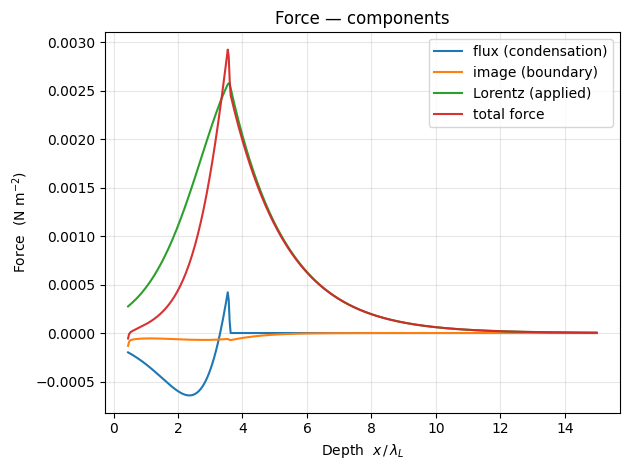

<Axes: title={'center': 'Force — components'}, xlabel='Depth  $x\\,/\\,\\lambda_L$', ylabel='Force  (N m$^{-2}$)'>

In [7]:
toy_plotter.plot_force(safe_slice=slice(15,-500))

A very particular phenomenon occurs here: the applied magnetic field gradient is further inwards, causing the lorentz force at the surface to be decreased. However, the fluxon condensation energy increases with depth, causing an effective negative force as the vortex attempts to expand [citation needed]. I'm not sure how physical this is. I've read a number of papers on imaging fluxons and measuring their superconducting order parameter supression, but I haven't read any that discuss their size changing as $\xi_s$ varies. Also, after some point the sign of the force swaps (visibly caused by the small bump in the Gibbs energy plot).
<div style="page-break-after: always"> </div>

<br>[10] 2014 CAS - CERN Accelerator School  [DOI](https://doi.org/10.5170/CERN-2014-005)
<br>[11] Diamagnetic Response of an N-S-Proximity System at Arbitrary Impurity Concentration [DOI](https://doi.org/10.1103/PhysRevB.58.14531)
<br>[12] Generalized Diffusion Equation for Superconducting Alloys [DOI](https://doi.org/10.1103/PhysRevLett.25.507)
<br>[13] Lucas Wallace - NUMERICALLY ESTIMATING THE SUPERHEATING FIELD OF SUPERCONDUCTORS WITH SPATIALLY VARYING IMPURITY  DISTRIBUTIONS [SRF2025](https://indico.jacow.org/event/89/contributions/11067), [pdf](https://meow.elettra.eu/89/pdf/TUP15.pdf)
<br>[14] Checchin & Grasselino - High-field Q-slope mitigation due to impurity profile in superconducting radio-frequency cavities  [DOI](https://doi.org/10.1063/5.0013698)
<br>[15] Clem - Simple model for the vortex core in a type II superconductor [DOI](https://doi.org/10.1007/BF00116134)
<br>[16] Hannah Hu et al. - Impact of Nitrogen and Oxygen Interstitials on Niobium SRF Cavity Performance  [DOI](https://doi.org/10.1063/5.0308624)
<br>[17] Strong Meissner screening change in superconducting radio frequency cavities due to  mild baking [DOI](https://doi.org/10.1063/1.4866013)
<!-- <br>[18] Nonlinear Dynamics and Dissipation of a Curvilinear Vortex Driven by a Strong  Time-Dependent Meissner Current [DOI](https://doi.org/10.1103/PhysRevB.101.064504) 
<br>[19] Oleksandr Dobrovolskiy - Fast dynamics of vortices in superconductors [DOI](https://doi.org/10.1016/B978-0-323-90800-9.00015-9) -->


<div style="page-break-after: always"> </div>